<a href="https://colab.research.google.com/github/lorek/MethodsClassDimRed/blob/main/MoCaDR_List_nr_11_transfer_learning_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Methods of classification and dimensionality reduction**

Paweł Lorek  
University of Wrocław

# NOTEBOOK NO 11, transfer learning



 <font face="Rage" size=2  > Updated: 14.06.2026 <font>

In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


In [ ]:
# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_CLASSES = 10


## Load CIFAR-10 data

In [ ]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# For plotting we keep an unnormalized version.
plot_transform = transforms.ToTensor()
plot_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=plot_transform)

In [ ]:
print(len(plot_train))

50000


In [ ]:


# For the logistic classifier and MLP we use pixels in [0, 1], like the Keras notebook.
basic_transform = transforms.ToTensor()
train_basic = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
test_basic = datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

train_loader_basic = DataLoader(train_basic, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_basic = DataLoader(test_basic, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
print(len(train_basic))
print(len(test_basic))

50000
10000


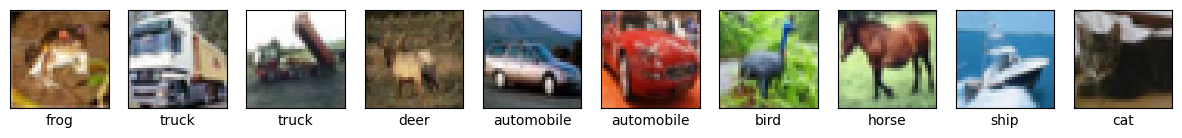

In [ ]:
# Function to display images with labels
def display_images(dataset, class_names, num_images=10):
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()
        plt.subplot(1, num_images, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(image)
        plt.xlabel(class_names[label])
    plt.show()

# Display images with labels
display_images(plot_train, class_names)


 ## Helper functions
 - count model parameters,
  - print a short model summary,
  - train one epoch,
  - evaluate a model,
  - run the full training loop.


In [ ]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return total, trainable


def print_model_summary(model):
    total, trainable = count_parameters(model)
    print(model)
    print(f'Total params: {total:,}')
    print(f'Trainable params: {trainable:,}')
    print(f'Non-trainable params: {total - trainable:,}')


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def fit(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=lr)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(
            f'Epoch {epoch}/{epochs} - '
            f'loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - '
            f'val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}'
        )

    training_time = time.time() - start_time
    print(f'Time taken for model fitting: {training_time:.2f} seconds')
    return history


# Logistic classifier

 This is a simple baseline model.

  Each image is flattened from `3 x 32 x 32` to a vector of length `3072`.
  The model has only one linear layer:

  `3072 -> 10`

  The 10 outputs correspond to the 10 CIFAR-10 classes. We do not add softmax in the model because `nn.CrossEntropyLoss` expects raw logits
  and applies the appropriate normalization internally.


In [ ]:
class LogisticClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3 * 32 * 32, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)


logistic_model = LogisticClassifier()
print_model_summary(logistic_model)


LogisticClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=3072, out_features=10, bias=True)
)
Total params: 30,730
Trainable params: 30,730
Non-trainable params: 0


In [ ]:
history_logistic = fit(logistic_model, train_loader_basic, test_loader_basic, epochs=EPOCHS, lr=LEARNING_RATE)


Epoch 1/10 - loss: 1.9246 - accuracy: 0.3217 - val_loss: 1.8214 - val_accuracy: 0.3663
Epoch 2/10 - loss: 1.8379 - accuracy: 0.3602 - val_loss: 1.8223 - val_accuracy: 0.3700
Epoch 3/10 - loss: 1.8137 - accuracy: 0.3699 - val_loss: 1.7645 - val_accuracy: 0.3805
Epoch 4/10 - loss: 1.7973 - accuracy: 0.3774 - val_loss: 1.8343 - val_accuracy: 0.3585
Epoch 5/10 - loss: 1.7851 - accuracy: 0.3815 - val_loss: 1.7952 - val_accuracy: 0.3669
Epoch 6/10 - loss: 1.7791 - accuracy: 0.3874 - val_loss: 1.8670 - val_accuracy: 0.3607
Epoch 7/10 - loss: 1.7665 - accuracy: 0.3922 - val_loss: 1.8226 - val_accuracy: 0.3673
Epoch 8/10 - loss: 1.7673 - accuracy: 0.3924 - val_loss: 1.8403 - val_accuracy: 0.3654
Epoch 9/10 - loss: 1.7633 - accuracy: 0.3920 - val_loss: 1.7892 - val_accuracy: 0.3754
Epoch 10/10 - loss: 1.7546 - accuracy: 0.3974 - val_loss: 1.7878 - val_accuracy: 0.3779
Time taken for model fitting: 95.67 seconds


In [ ]:
criterion = nn.CrossEntropyLoss()
logistic_test_loss, logistic_test_accuracy = evaluate(logistic_model, test_loader_basic, criterion, DEVICE)
print(f'Logistic Classifier: Test loss: {logistic_test_loss:.4f}, Test accuracy: {logistic_test_accuracy:.4f}')


Logistic Classifier: Test loss: 1.7878, Test accuracy: 0.3779


# MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp_model = MLP()
print_model_summary(mlp_model)


MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total params: 855,050
Trainable params: 855,050
Non-trainable params: 0


In [ ]:
history_mlp = fit(mlp_model, train_loader_basic, test_loader_basic, epochs=EPOCHS, lr=LEARNING_RATE)


Epoch 1/10 - loss: 1.8407 - accuracy: 0.3308 - val_loss: 1.7056 - val_accuracy: 0.3896
Epoch 2/10 - loss: 1.6598 - accuracy: 0.4045 - val_loss: 1.6086 - val_accuracy: 0.4179
Epoch 3/10 - loss: 1.5701 - accuracy: 0.4377 - val_loss: 1.5618 - val_accuracy: 0.4442
Epoch 4/10 - loss: 1.5162 - accuracy: 0.4573 - val_loss: 1.5299 - val_accuracy: 0.4538
Epoch 5/10 - loss: 1.4820 - accuracy: 0.4696 - val_loss: 1.5059 - val_accuracy: 0.4677
Epoch 6/10 - loss: 1.4387 - accuracy: 0.4855 - val_loss: 1.4560 - val_accuracy: 0.4826
Epoch 7/10 - loss: 1.4159 - accuracy: 0.4928 - val_loss: 1.4715 - val_accuracy: 0.4809
Epoch 8/10 - loss: 1.3908 - accuracy: 0.5013 - val_loss: 1.4383 - val_accuracy: 0.4834
Epoch 9/10 - loss: 1.3612 - accuracy: 0.5140 - val_loss: 1.4322 - val_accuracy: 0.4858
Epoch 10/10 - loss: 1.3447 - accuracy: 0.5176 - val_loss: 1.4341 - val_accuracy: 0.4893
Time taken for model fitting: 101.81 seconds


In [ ]:
mlp_test_loss, mlp_test_accuracy = evaluate(mlp_model, test_loader_basic, criterion, DEVICE)
print(f'MLP: Test loss: {mlp_test_loss:.4f}, Test accuracy: {mlp_test_accuracy:.4f}')


MLP: Test loss: 1.4341, Test accuracy: 0.4893


## Simple CNN

In [ ]:
class SimpleCNN(nn.Module):
      def __init__(self, num_classes=NUM_CLASSES):
          super().__init__()
          self.features = nn.Sequential(
              nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3 x 32 x 32 -> 32 x 32 x 32
              nn.ReLU(),
              nn.MaxPool2d(kernel_size=2),                  # 32 x 32 x 32 -> 32 x 16 x 16

              nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 32 x 16 x 16 -> 64 x 16 x 16
              nn.ReLU(),
              nn.MaxPool2d(kernel_size=2),                  # 64 x 16 x 16 -> 64 x 8 x 8
          )

          self.classifier = nn.Sequential(
              nn.Flatten(),
              nn.Linear(64 * 8 * 8, 256),
              nn.ReLU(),
              nn.Linear(256, num_classes),
          )

      def forward(self, x):
          x = self.features(x)
          return self.classifier(x)


In [ ]:
cnn_model = SimpleCNN()
print_model_summary(cnn_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total params: 1,070,794
Trainable params: 1,070,794
Non-trainable params: 0


In [ ]:
time_start = time.time()

history_cnn = fit(
      cnn_model,
      train_loader_basic,
      test_loader_basic,
      epochs=EPOCHS,
      lr=LEARNING_RATE
  )

time_end = time.time()

print(f"Took: {time_end - time_start:.2f} seconds")

Epoch 1/10 - loss: 1.4277 - accuracy: 0.4873 - val_loss: 1.1884 - val_accuracy: 0.5807
Epoch 2/10 - loss: 1.0580 - accuracy: 0.6260 - val_loss: 0.9700 - val_accuracy: 0.6589
Epoch 3/10 - loss: 0.8928 - accuracy: 0.6879 - val_loss: 0.9293 - val_accuracy: 0.6735
Epoch 4/10 - loss: 0.7718 - accuracy: 0.7289 - val_loss: 0.8907 - val_accuracy: 0.6923
Epoch 5/10 - loss: 0.6720 - accuracy: 0.7631 - val_loss: 0.8572 - val_accuracy: 0.7075
Epoch 6/10 - loss: 0.5817 - accuracy: 0.7948 - val_loss: 0.8358 - val_accuracy: 0.7188
Epoch 7/10 - loss: 0.4852 - accuracy: 0.8315 - val_loss: 0.8796 - val_accuracy: 0.7223
Epoch 8/10 - loss: 0.3984 - accuracy: 0.8607 - val_loss: 0.9125 - val_accuracy: 0.7211
Epoch 9/10 - loss: 0.3158 - accuracy: 0.8911 - val_loss: 1.0353 - val_accuracy: 0.7098
Epoch 10/10 - loss: 0.2513 - accuracy: 0.9139 - val_loss: 1.0541 - val_accuracy: 0.7206
Time taken for model fitting: 111.69 seconds
Took: 111.70 seconds


In [ ]:
cnn_test_loss, cnn_test_accuracy = evaluate(cnn_model, test_loader_basic, criterion, DEVICE)
print(f"Simple CNN: Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_accuracy:.4f}")


Simple CNN: Test loss: 1.0541, Test accuracy: 0.7206


 ## Feature maps

  Feature maps show how convolutional filters respond to an input image.
  Each map corresponds to one learned filter from a convolutional layer.

  Bright regions indicate stronger activation of that filter.

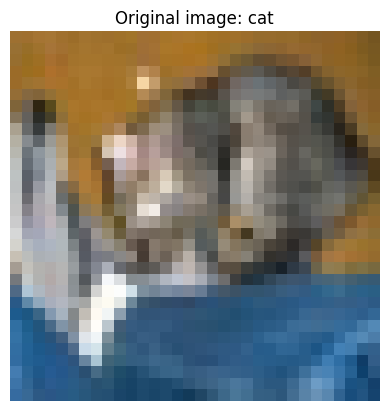

In [ ]:
# Take one test image
image, label = test_basic[0]

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Original image: {class_names[label]}")
plt.axis("off")
plt.show()


torch.Size([1, 32, 32, 32])


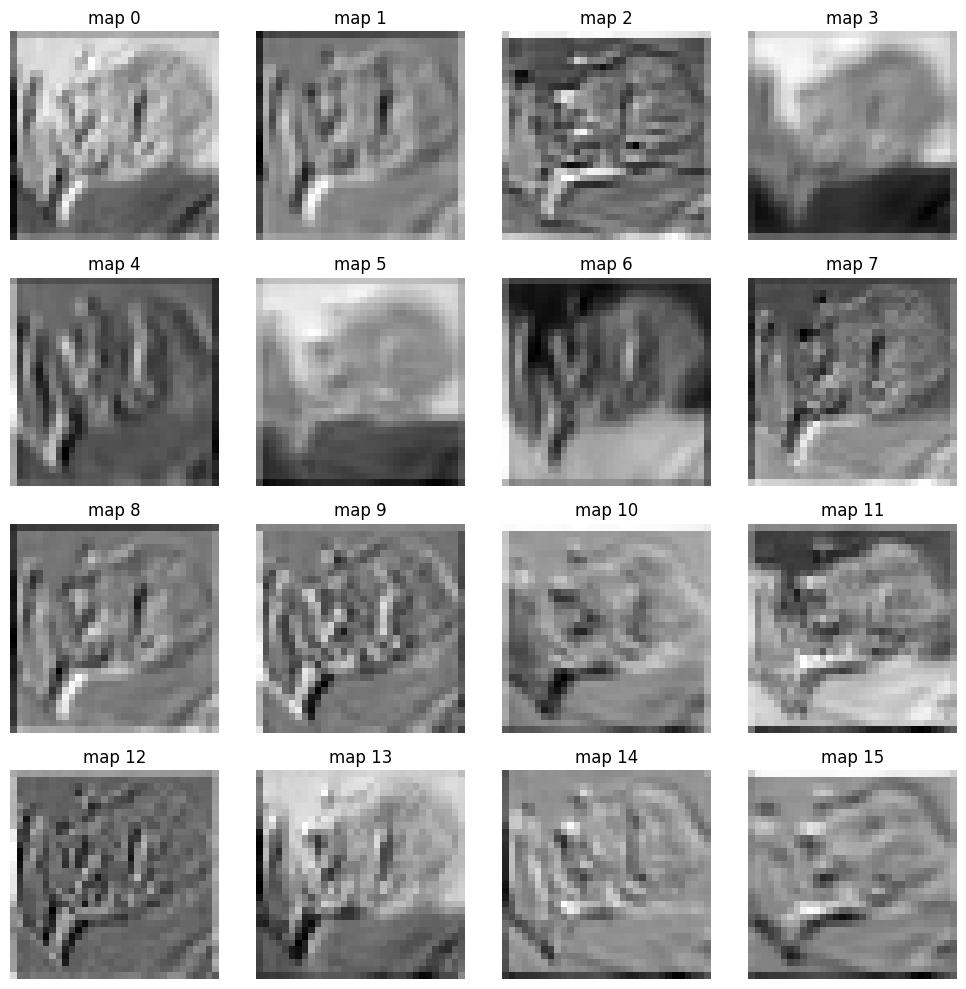

In [ ]:
cnn_model.eval()

# Add batch dimension: 3 x 32 x 32 -> 1 x 3 x 32 x 32
image_batch = image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
  first_conv = cnn_model.features[0]
  feature_maps = first_conv(image_batch)
print(feature_maps.shape)

feature_maps = feature_maps.squeeze(0).cpu()

num_maps = 16
plt.figure(figsize=(10, 10))

for i in range(num_maps):
  plt.subplot(4, 4, i + 1)
  plt.imshow(feature_maps[i], cmap="gray")
  plt.axis("off")
  plt.title(f"map {i}")

plt.tight_layout()
plt.show()

# TRANSFER LEARNING
## Load relatively large VGG16 trained on ImageNet

**ImageNet Dataset**
* ImageNet is a large visual database designed for use in visual object recognition software research.
* It contains over 14 million images across more than 20,000 categories.
* The VGG16 model, along with other popular architectures like ResNet, Inception, and AlexNet, was originally trained on ImageNet to classify images into 1,000 categories.

**VGG16 Model**
* **VGG16** is a deep convolutional neural network architecture proposed by the Visual Geometry Group (VGG) at the University of Oxford.
* It has 13 convolutional layers and 3 fully connected layers in its original classifier.
* In transfer learning below we use the convolutional feature extractor and add a small CIFAR-10 classifier.


Model **with** top layers (just to see architecture)

In [ ]:
try:
    vgg_weights = models.VGG16_Weights.IMAGENET1K_V1
    base_model_with = models.vgg16(weights=vgg_weights)
except AttributeError:
    # Fallback for older torchvision versions.
    vgg_weights = None
    base_model_with = models.vgg16(pretrained=True)

print_model_summary(base_model_with)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 130MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

![VGG16b](https://raw.githubusercontent.com/lorek/datasets/refs/heads/master/cnn_pics/cnn_vgg-16_arch1.png))

![VGG16b](https://raw.githubusercontent.com/lorek/datasets/refs/heads/master/cnn_pics/cnn_vgg-16_arch2.png))

Note last layer: 4096 -> 1000 since there was 1000 classes (trained on ImageNet with 1000 classes)

# VGG16 Transfer learning, VERSION 1

Model **WITHOUT** top classifier layers

Pretrained VGG16 expects images normalized in the same way
as during ImageNet training. Therefore we create separate
CIFAR-10 loaders for the transfer learning part.


In [ ]:
# ImageNet normalization expected by pretrained torchvision VGG16 weights.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

vgg_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_vgg = datasets.CIFAR10(root='./data', train=True, download=True, transform=vgg_transform)
test_vgg = datasets.CIFAR10(root='./data', train=False, download=True, transform=vgg_transform)

train_loader_vgg = DataLoader(train_vgg, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_vgg = DataLoader(test_vgg, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


 Here we load only the convolutional feature extractor from VGG16.

  This corresponds to keeping the blue/yellow part in the diagram above and removing the green Dense classifier.

  Keras:

  `VGG16(weights='imagenet', include_top=False)`

  PyTorch:

  `models.vgg16(weights=vgg_weights).features`

  The `.features` module contains the convolution and pooling layers, but not the original ImageNet Dense classifier.


![VGG16c](https://raw.githubusercontent.com/lorek/datasets/refs/heads/master/cnn_pics/cnn_vgg-16_arch2_top_removed.jpg)

In [ ]:
try:
    base_model = models.vgg16(weights=vgg_weights).features
except TypeError:
    base_model = models.vgg16(pretrained=True).features

print_model_summary(base_model)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

**FREEZE** these layers -- we do not want to train them

In [ ]:
for name, param in base_model.named_parameters():
    print('layer = ', name)
    param.requires_grad = False


layer =  0.weight
layer =  0.bias
layer =  2.weight
layer =  2.bias
layer =  5.weight
layer =  5.bias
layer =  7.weight
layer =  7.bias
layer =  10.weight
layer =  10.bias
layer =  12.weight
layer =  12.bias
layer =  14.weight
layer =  14.bias
layer =  17.weight
layer =  17.bias
layer =  19.weight
layer =  19.bias
layer =  21.weight
layer =  21.bias
layer =  24.weight
layer =  24.bias
layer =  26.weight
layer =  26.bias
layer =  28.weight
layer =  28.bias


In [ ]:
class VGG16Transfer(nn.Module):
    def __init__(self, features, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)  # CIFAR-10 32x32 -> 512 x 1 x 1 after VGG16 feature extractor
        return self.classifier(x)


transfer_model = VGG16Transfer(base_model)
print_model_summary(transfer_model)


VGG16Transfer(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [ ]:
history_transfer = fit(transfer_model, train_loader_vgg, test_loader_vgg, epochs=EPOCHS, lr=LEARNING_RATE)


Epoch 1/10 - loss: 1.0851 - accuracy: 0.6217 - val_loss: 0.9486 - val_accuracy: 0.6665
Epoch 2/10 - loss: 0.9406 - accuracy: 0.6687 - val_loss: 0.8976 - val_accuracy: 0.6821
Epoch 3/10 - loss: 0.8931 - accuracy: 0.6849 - val_loss: 0.8842 - val_accuracy: 0.6878
Epoch 4/10 - loss: 0.8605 - accuracy: 0.6964 - val_loss: 0.8764 - val_accuracy: 0.6911
Epoch 5/10 - loss: 0.8301 - accuracy: 0.7088 - val_loss: 0.8685 - val_accuracy: 0.6946
Epoch 6/10 - loss: 0.8077 - accuracy: 0.7141 - val_loss: 0.8710 - val_accuracy: 0.6976
Epoch 7/10 - loss: 0.7830 - accuracy: 0.7232 - val_loss: 0.8759 - val_accuracy: 0.6959
Epoch 8/10 - loss: 0.7582 - accuracy: 0.7299 - val_loss: 0.8868 - val_accuracy: 0.6943
Epoch 9/10 - loss: 0.7407 - accuracy: 0.7376 - val_loss: 0.8838 - val_accuracy: 0.6994
Epoch 10/10 - loss: 0.7218 - accuracy: 0.7402 - val_loss: 0.8861 - val_accuracy: 0.6985
Time taken for model fitting: 179.14 seconds


In [ ]:
test_loss, test_accuracy = evaluate(transfer_model, test_loader_vgg, criterion, DEVICE)
print(f'Transfer learning VGG16: Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}')


Transfer learning VGG16: Test loss: 0.8861, Test accuracy: 0.6985


# VGG16 Transfer learning, VERSION 2

In [ ]:
class VGG16LastLayerPlusHead(nn.Module):
      def __init__(self, num_classes=NUM_CLASSES):
          super().__init__()

          self.vgg = models.vgg16(weights=vgg_weights)

          # Freeze everything first
          for param in self.vgg.parameters():
              param.requires_grad = False

          # Unfreeze only the original ImageNet final layer: 4096 -> 1000
          for param in self.vgg.classifier[6].parameters():
              param.requires_grad = True

          # Add new CIFAR-10 classification layer: 1000 -> 10
          self.cifar_head = nn.Linear(1000, num_classes)

      def forward(self, x):
          x = self.vgg(x)          # output: 1000 ImageNet logits
          x = self.cifar_head(x)   # output: 10 CIFAR-10 logits
          return x


In [ ]:
transfer_model_1000 = VGG16LastLayerPlusHead()
print_model_summary(transfer_model_1000)

VGG16LastLayerPlusHead(
  (vgg): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)

In [ ]:
 history_transfer_1000 = fit(
      transfer_model_1000,
      train_loader_vgg,
      test_loader_vgg,
      epochs=EPOCHS,
      lr=LEARNING_RATE
  )

Epoch 1/10 - loss: 1.7196 - accuracy: 0.5204 - val_loss: 1.2149 - val_accuracy: 0.5837
Epoch 2/10 - loss: 1.3859 - accuracy: 0.5407 - val_loss: 1.1836 - val_accuracy: 0.5882
Epoch 3/10 - loss: 1.4349 - accuracy: 0.5420 - val_loss: 1.1965 - val_accuracy: 0.5978
Epoch 4/10 - loss: 1.4809 - accuracy: 0.5452 - val_loss: 1.2402 - val_accuracy: 0.5947
Epoch 5/10 - loss: 1.5126 - accuracy: 0.5437 - val_loss: 1.2277 - val_accuracy: 0.5985
Epoch 6/10 - loss: 1.5558 - accuracy: 0.5399 - val_loss: 1.3124 - val_accuracy: 0.5827
Epoch 7/10 - loss: 1.5716 - accuracy: 0.5432 - val_loss: 1.2554 - val_accuracy: 0.5734
Epoch 8/10 - loss: 1.5826 - accuracy: 0.5473 - val_loss: 1.2887 - val_accuracy: 0.5743
Epoch 9/10 - loss: 1.6008 - accuracy: 0.5443 - val_loss: 1.2602 - val_accuracy: 0.5996
Epoch 10/10 - loss: 1.6222 - accuracy: 0.5446 - val_loss: 1.3001 - val_accuracy: 0.5878
Time taken for model fitting: 194.56 seconds


# ResNet

ResNet18 was pretrained on ImageNet-1K, a large dataset with 1000 classes.
  We replace its original ImageNet classifier with a new layer for the 10 CIFAR-10 classes.

  Unlike VGG16, ResNet uses residual connections, which usually makes training and fine-tuning easier.
  Here we can first train only the new final layer, and then optionally unfreeze the last residual block for fine-tuning.

In [ ]:
resnet_weights = models.ResNet18_Weights.IMAGENET1K_V1

resnet_transform = transforms.Compose([
      transforms.Resize((224, 224)),  # ResNet was trained on larger ImageNet images
      transforms.ToTensor(),
      transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225],
      ),
  ])


In [ ]:
test_resnet = datasets.CIFAR10(
      root="./data",
      train=False,
      download=True,
      transform=resnet_transform
  )

train_resnet = datasets.CIFAR10(
      root="./data",
      train=True,
      download=True,
      transform=resnet_transform
  )

train_loader_resnet = DataLoader(
      train_resnet,
      batch_size=BATCH_SIZE,
      shuffle=True,
      num_workers=2,
      pin_memory=True
  )

test_loader_resnet = DataLoader(
      test_resnet,
      batch_size=BATCH_SIZE,
      shuffle=False,
      num_workers=2,
      pin_memory=True
  )


In [ ]:
resnet_model = models.resnet18(weights=resnet_weights)

  # Freeze ALL pretrained layers
for param in resnet_model.parameters():
  param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


In [ ]:
# Replace the original ImageNet classifier: 512 -> 1000
# with a new CIFAR-10 classifier: 512 -> 10
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, NUM_CLASSES)

In [ ]:
print_model_summary(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
history_resnet = fit(
      resnet_model,
      train_loader_resnet,
      test_loader_resnet,
      epochs=EPOCHS,
      lr=LEARNING_RATE
  )


Epoch 1/10 - loss: 0.8306 - accuracy: 0.7320 - val_loss: 0.6336 - val_accuracy: 0.7873
Epoch 2/10 - loss: 0.6168 - accuracy: 0.7880 - val_loss: 0.6175 - val_accuracy: 0.7914
Epoch 3/10 - loss: 0.5911 - accuracy: 0.7956 - val_loss: 0.5865 - val_accuracy: 0.8015
Epoch 4/10 - loss: 0.5756 - accuracy: 0.8013 - val_loss: 0.5969 - val_accuracy: 0.7938
Epoch 5/10 - loss: 0.5650 - accuracy: 0.8034 - val_loss: 0.5950 - val_accuracy: 0.7996
Epoch 6/10 - loss: 0.5621 - accuracy: 0.8048 - val_loss: 0.5781 - val_accuracy: 0.8043
Epoch 7/10 - loss: 0.5587 - accuracy: 0.8058 - val_loss: 0.5925 - val_accuracy: 0.7984
Epoch 8/10 - loss: 0.5525 - accuracy: 0.8074 - val_loss: 0.5615 - val_accuracy: 0.8077
Epoch 9/10 - loss: 0.5476 - accuracy: 0.8092 - val_loss: 0.5609 - val_accuracy: 0.8097
Epoch 10/10 - loss: 0.5457 - accuracy: 0.8111 - val_loss: 0.5790 - val_accuracy: 0.8012
Time taken for model fitting: 1064.05 seconds


In [ ]:
resnet_test_loss, resnet_test_accuracy = evaluate(
      resnet_model,
      test_loader_resnet,
      criterion,
      DEVICE
  )

print(f"ResNet18 transfer learning: Test loss: {resnet_test_loss:.4f}, Test accuracy: {resnet_test_accuracy:.4f}")


ResNet18 transfer learning: Test loss: 0.5790, Test accuracy: 0.8012


Ranking of algorithms/networks for CIFAR-10:

https://paperswithcode.com/sota/image-classification-on-cifar-10

https://hyper.ai/en/sota/tasks/image-classification/benchmark/image-classification-on-cifar-10


# Q13.1 **TO DO**